In [1]:
# =============================================================================
# CELL 1: Imports
# =============================================================================
# OpenEye toolkits for 3D conformer generation and shape overlay
from openeye import oechem, oequacpac, oeomega, oeshape

# Data handling and ML
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor

# Evaluation metrics
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# =============================================================================
# CELL 2: Load the Dataset
# =============================================================================
# Load the CSV file containing SMILES, set labels, and pIC50 targets
df = pd.read_csv("antiviral_potency_2025_unblinded.csv")

# Quick look at the data
print(f"Total molecules: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Total molecules: 1328
Columns: ['CXSMILES', 'Molecule Name', 'Set', 'pIC50 (MERS-CoV Mpro)', 'pIC50 (SARS-CoV-2 Mpro)']

First few rows:


,CXSMILES,Molecule Name,Set,pIC50 (MERS-CoV Mpro),pIC50 (SARS-CoV-2 Mpro)
0,COC[C@]1(C)C(=O)N(C2=CN=CC3=CC=CC=C23)C(=O)N1C...,ASAP-0000141,Train,4.19,NaN
1,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000142,Train,4.92,5.29
2,CNC(=O)CN1C[C@]2(C[C@H](C)N(C3=CN=CC=C3C3CC3)C...,ASAP-0000143,Train,4.73,NaN
3,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000144,Train,4.90,6.11
4,C=C(CN1CCC2=C(C=C(Cl)C=C2)C1C(=O)NC1=CN=CC2=CC...,ASAP-0000145,Train,4.81,5.62


In [3]:
# =============================================================================
# CELL 3: Select Target and Filter Missing Values
# =============================================================================
# Choose which target to model — change this to switch targets
# Options: "pIC50 (MERS-CoV Mpro)" or "pIC50 (SARS-CoV-2 Mpro)"
TARGET = "pIC50 (SARS-CoV-2 Mpro)"

# Keep only the columns we need and drop rows with missing pIC50
working_df = df[["CXSMILES", "Molecule Name", "Set", TARGET]].dropna(subset=[TARGET])

print(f"Molecules with valid {TARGET}: {len(working_df)}")
print(f"\nSet distribution:")
print(working_df["Set"].value_counts())
print(f"\npIC50 summary statistics:")
print(working_df[TARGET].describe())

Molecules with valid pIC50 (SARS-CoV-2 Mpro): 1105

Set distribution:
Set
Train    842
Test     263
Name: count, dtype: int64

pIC50 summary statistics:
count    1105.000000
mean        5.543620
std         1.165263
min         4.000000
25%         4.570000
50%         5.230000
75%         6.370000
max         8.730000
Name: pIC50 (SARS-CoV-2 Mpro), dtype: float64


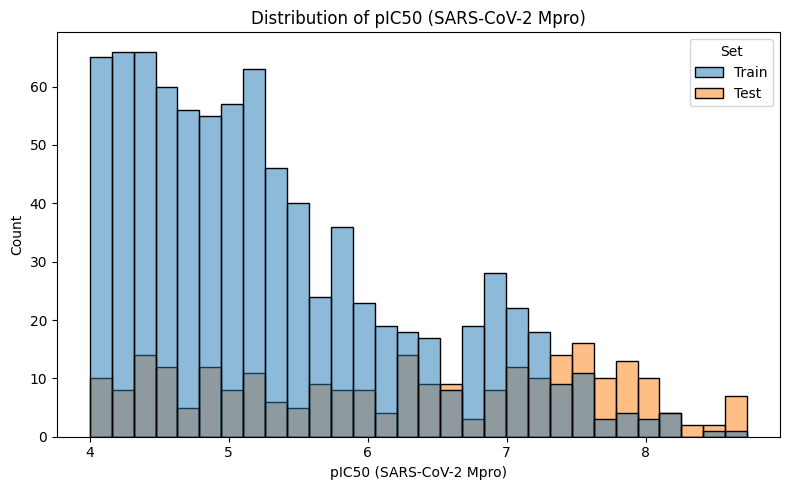

In [4]:
# =============================================================================
# CELL 4: Visualize the Target Distribution
# =============================================================================
# Plot histogram of pIC50 values to understand the distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=working_df, x=TARGET, hue="Set", bins=30, ax=ax)
ax.set_title(f"Distribution of {TARGET}")
ax.set_xlabel(TARGET)
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# CELL 5: Generate 3D Conformers Using Omega
# =============================================================================
# Omega generates realistic 3D coordinates from 2D SMILES
# OEFlipper handles stereochemistry enumeration
# These 3D structures are required for ROCS shape overlay

omega_opts = oeomega.OEOmegaOptions(oeomega.OEOmegaSampling_ROCS)
omega = oeomega.OEOmega(omega_opts)
flipper_opts = oeomega.OEFlipperOptions()
flipper_opts.SetMaxCenters(3)  # Limit stereo enumeration to keep things manageable

# Progress tracker
dots = oechem.OEDots(100, 10, "molecules", "processed")

# Output file for 3D conformers
ofs = oechem.oemolostream("conformers_3d.oez")

# Track which molecules successfully got conformers
successful_indices = []
title_idx = 0

for idx, row in working_df.iterrows():
    smiles = row["CXSMILES"]
    pic50 = row[TARGET]
    mol_name = row["Molecule Name"]
    mol_set = row["Set"]

    mol = oechem.OEMol()
    oechem.OESmilesToMol(mol, smiles)

    # Try each stereoisomer, keep the first successful one
    for isomer in oeomega.OEFlipper(mol, flipper_opts):
        fmol = oechem.OEMol(isomer)
        ret_code = omega.Build(fmol)

        if ret_code == oeomega.OEOmegaReturnCode_Success:
            # Store metadata as SD tags on the molecule
            fmol.SetTitle(str(title_idx))
            oechem.OESetSDData(fmol, "pIC50", str(pic50))
            oechem.OESetSDData(fmol, "Set", mol_set)
            oechem.OESetSDData(fmol, "MolName", str(mol_name))
            oechem.OEWriteMolecule(ofs, fmol)

            successful_indices.append(idx)
            title_idx += 1
            dots.Update()
            break  # Only keep one conformer per molecule

ofs.close()
print(f"\nSuccessfully generated conformers for {title_idx} molecules")


Successfully generated conformers for 1098 molecules


In [6]:
# =============================================================================
# CELL 6: Load Conformers Back Into Memory
# =============================================================================
# Read all conformers from the .oez file into a list for ROCS overlay
ifs = oechem.oemolistream("conformers_3d.oez")

mol_list = []
pic50_values = []
set_labels = []
mol_names = []

for mol in ifs.GetOEMols():
    mol_list.append(oechem.OEMol(mol))
    pic50_values.append(float(oechem.OEGetSDData(mol, "pIC50")))
    set_labels.append(oechem.OEGetSDData(mol, "Set"))
    mol_names.append(oechem.OEGetSDData(mol, "MolName"))

ifs.close()

N = len(mol_list)
print(f"Loaded {N} molecules with conformers")
print(f"Train: {set_labels.count('train')}, Test: {set_labels.count('test')}")

Loaded 1098 molecules with conformers
Train: 0, Test: 0


In [8]:
# =============================================================================
# CELL 7: Compute ROCS Shape and Color Similarity Matrices
# =============================================================================
# For each pair of molecules, ROCS overlays them in 3D and scores:
#   - Shape Tanimoto: how much 3D volume overlaps (0 to 1)
#   - Color Tanimoto: how well pharmacophore features align (0 to 1)
# We store these SEPARATELY to give the model more granular information

# Initialize two N x N matrices
shape_matrix = np.zeros((N, N))
color_matrix = np.zeros((N, N))

prep = oeshape.OEOverlapPrep()
timer = oechem.OEWallTimer()

for i, query in enumerate(mol_list):
    # Prepare the query (reference) molecule
    prep.Prep(query)
    overlay = oeshape.OEOverlay()
    overlay.SetupRef(query)

    for j, fitmol in enumerate(mol_list):
        # Prepare the fit molecule
        prep.Prep(fitmol)

        # Find the best overlay and score it
        score = oeshape.OEBestOverlayScore()
        overlay.BestOverlay(score, fitmol)

        # Store shape and color scores separately
        shape_matrix[i][j] = score.GetShapeTanimoto()
        color_matrix[i][j] = score.GetColorTanimoto()

    # Print progress every 50 molecules
    if (i + 1) % 50 == 0 or (i + 1) == N:
        elapsed = timer.Elapsed()
        pct = (i + 1) / N * 100
        est_total = elapsed / (i + 1) * N
        est_remaining = est_total - elapsed
        print(f"[{i+1}/{N}] {pct:.1f}% done | "
              f"Elapsed: {elapsed/60:.1f} min | "
              f"Est. remaining: {est_remaining/60:.1f} min")

elapsed = timer.Elapsed()
print(f"\nROCS overlay completed in {elapsed/60:.1f} minutes ({elapsed:.1f} seconds)")

# Save matrices so you don't have to recompute (this step is slow!)
np.save("shape_matrix.npy", shape_matrix)
np.save("color_matrix.npy", color_matrix)
print("Matrices saved to disk")

[50/1098] 4.6% done | Elapsed: 14.8 min | Est. remaining: 310.3 min
[100/1098] 9.1% done | Elapsed: 25.6 min | Est. remaining: 255.4 min
[150/1098] 13.7% done | Elapsed: 37.0 min | Est. remaining: 233.6 min
[200/1098] 18.2% done | Elapsed: 46.4 min | Est. remaining: 208.4 min
[250/1098] 22.8% done | Elapsed: 56.0 min | Est. remaining: 190.0 min
[300/1098] 27.3% done | Elapsed: 66.8 min | Est. remaining: 177.8 min
[350/1098] 31.9% done | Elapsed: 79.2 min | Est. remaining: 169.3 min
[400/1098] 36.4% done | Elapsed: 90.4 min | Est. remaining: 157.7 min
[450/1098] 41.0% done | Elapsed: 100.7 min | Est. remaining: 145.1 min
[500/1098] 45.5% done | Elapsed: 111.8 min | Est. remaining: 133.7 min
[550/1098] 50.1% done | Elapsed: 124.4 min | Est. remaining: 124.0 min
[600/1098] 54.6% done | Elapsed: 135.7 min | Est. remaining: 112.7 min
[650/1098] 59.2% done | Elapsed: 146.3 min | Est. remaining: 100.8 min
[700/1098] 63.8% done | Elapsed: 156.5 min | Est. remaining: 89.0 min
[750/1098] 68.3% d

In [9]:
# =============================================================================
# CELL 8: Build the Feature Matrix
# =============================================================================
# If you already computed and saved the matrices, load them here:
# shape_matrix = np.load("shape_matrix.npy")
# color_matrix = np.load("color_matrix.npy")

# Concatenate shape and color matrices side by side
# Each molecule now has 2N features: [shape_vs_all, color_vs_all]
features = np.concatenate([shape_matrix, color_matrix], axis=1)
target = np.array(pic50_values)
sets = np.array(set_labels)

print(f"Feature matrix shape: {features.shape}")
print(f"  - {N} shape features + {N} color features = {2*N} total features per molecule")
print(f"Target array shape: {target.shape}")

Feature matrix shape: (1098, 2196)
  - 1098 shape features + 1098 color features = 2196 total features per molecule
Target array shape: (1098,)


In [14]:
# =============================================================================
# CELL 9: Train/Test Split Using the Set Column
# =============================================================================
# Use the predefined train/test split from the dataset
# (Do NOT use random split — this preserves the benchmark evaluation)
train_mask = sets == "Train"
test_mask = sets == "Test"

train_X = features[train_mask]
train_y = target[train_mask]
test_X = features[test_mask]
test_y = target[test_mask]

print(f"Training set: {train_X.shape[0]} molecules, {train_X.shape[1]} features")
print(f"Test set:     {test_X.shape[0]} molecules, {test_X.shape[1]} features")

Training set: 836 molecules, 2196 features
Test set:     262 molecules, 2196 features


In [13]:
print(working_df["Set"].unique())

['Train' 'Test']


In [15]:
# =============================================================================
# CELL 10: Train LightGBM Model
# =============================================================================
# LightGBM is a gradient boosting framework — fast, handles high-dimensional
# data well, and works nicely with similarity-based features

lgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,       # No depth limit
    num_leaves=31,      # Default
    random_state=42,
    verbosity=-1        # Suppress warnings
)

lgbm.fit(train_X, train_y)
print("Model training complete")

Model training complete


In [16]:
# =============================================================================
# CELL 11: Predict and Evaluate
# =============================================================================
# Predict pIC50 on the test set
pred = lgbm.predict(test_X)

# Calculate metrics
rho, p_value = spearmanr(test_y, pred)
mae = mean_absolute_error(test_y, pred)
rmse = root_mean_squared_error(test_y, pred)

print("=" * 50)
print(f"MODEL PERFORMANCE — {TARGET}")
print("=" * 50)
print(f"Spearman rho:  {rho:.4f}  (ranking correlation)")
print(f"MAE:           {mae:.4f}  (avg prediction error)")
print(f"RMSE:          {rmse:.4f}  (penalizes large errors)")
print("=" * 50)

MODEL PERFORMANCE — pIC50 (SARS-CoV-2 Mpro)
Spearman rho:  0.8092  (ranking correlation)
MAE:           0.6182  (avg prediction error)
RMSE:          0.8333  (penalizes large errors)


c:\Users\jxzor\miniconda3\envs\openeye\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


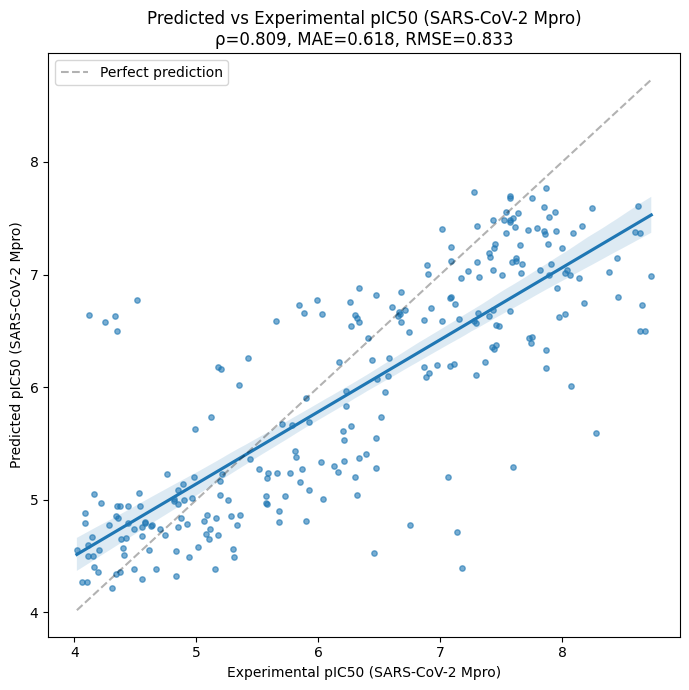

In [17]:
# =============================================================================
# CELL 12: Predicted vs Experimental Scatter Plot
# =============================================================================
# Points on the diagonal = perfect predictions
# Spread around diagonal = prediction error
fig, ax = plt.subplots(figsize=(7, 7))
sns.regplot(x=test_y, y=pred, scatter_kws={"s": 15, "alpha": 0.6}, ax=ax)

# Add diagonal reference line
min_val = min(test_y.min(), pred.min())
max_val = max(test_y.max(), pred.max())
ax.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.3, label="Perfect prediction")

ax.set_xlabel(f"Experimental {TARGET}")
ax.set_ylabel(f"Predicted {TARGET}")
ax.set_title(f"Predicted vs Experimental {TARGET}\nρ={rho:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
ax.legend()
plt.tight_layout()
plt.show()


Total Shape feature importance: 1647
Total Color feature importance: 1352
Shape / Color ratio: 1.22


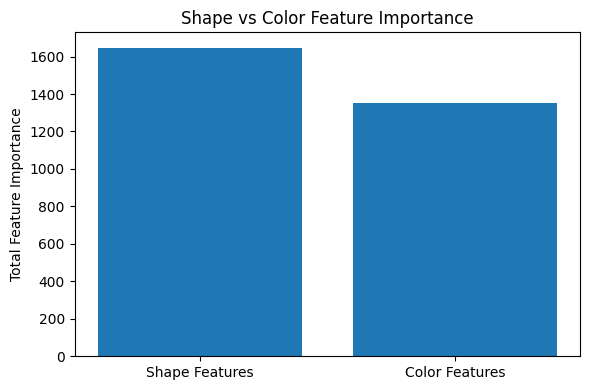

In [18]:
# =============================================================================
# CELL 13: Feature Importance (Optional but Useful)
# =============================================================================
# See which similarity features the model relies on most
# First N features = shape similarities, last N features = color similarities
importances = lgbm.feature_importances_
shape_importance = importances[:N].sum()
color_importance = importances[N:].sum()

print(f"Total Shape feature importance: {shape_importance}")
print(f"Total Color feature importance: {color_importance}")
print(f"Shape / Color ratio: {shape_importance / max(color_importance, 1):.2f}")

# Bar chart comparing shape vs color importance
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Shape Features", "Color Features"], [shape_importance, color_importance])
ax.set_ylabel("Total Feature Importance")
ax.set_title("Shape vs Color Feature Importance")
plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# CELL 14: Training Set Performance (Sanity Check)
# =============================================================================
# Check if the model is overfitting by comparing train vs test performance
train_pred = lgbm.predict(train_X)

train_rho, _ = spearmanr(train_y, train_pred)
train_mae = mean_absolute_error(train_y, train_pred)
train_rmse = root_mean_squared_error(train_y, train_pred)

print("=" * 50)
print("TRAIN vs TEST COMPARISON")
print("=" * 50)
print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
print(f"{'Spearman rho':<15} {train_rho:>10.4f} {rho:>10.4f}")
print(f"{'MAE':<15} {train_mae:>10.4f} {mae:>10.4f}")
print(f"{'RMSE':<15} {train_rmse:>10.4f} {rmse:>10.4f}")
print("=" * 50)
# Large gap between train and test = overfitting
# Similar values = model generalizes well

TRAIN vs TEST COMPARISON
Metric               Train       Test
Spearman rho        0.9802     0.8092
MAE                 0.0702     0.6182
RMSE                0.1850     0.8333


c:\Users\jxzor\miniconda3\envs\openeye\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
